
Running ablation: baseline
Eval num_timesteps=20000, episode_reward=-99.60 +/- 0.73
Episode length: 53.40 +/- 0.80
New best mean reward!
Eval num_timesteps=40000, episode_reward=-65.65 +/- 25.01
Episode length: 1253.40 +/- 914.43
New best mean reward!
Eval num_timesteps=60000, episode_reward=-91.14 +/- 1.80
Episode length: 117.80 +/- 15.12
Eval num_timesteps=80000, episode_reward=-92.57 +/- 2.53
Episode length: 124.20 +/- 18.67
Eval num_timesteps=100000, episode_reward=-32.65 +/- 11.89
Episode length: 2000.00 +/- 0.00
New best mean reward!
Eval num_timesteps=120000, episode_reward=-46.29 +/- 14.78
Episode length: 2000.00 +/- 0.00
Eval num_timesteps=140000, episode_reward=-46.22 +/- 22.24
Episode length: 2000.00 +/- 0.00
Eval num_timesteps=160000, episode_reward=-31.24 +/- 0.42
Episode length: 2000.00 +/- 0.00
New best mean reward!
Eval num_timesteps=180000, episode_reward=-41.14 +/- 1.66
Episode length: 2000.00 +/- 0.00
Eval num_timesteps=200000, episode_reward=-44.10 +/- 0.70
Episode

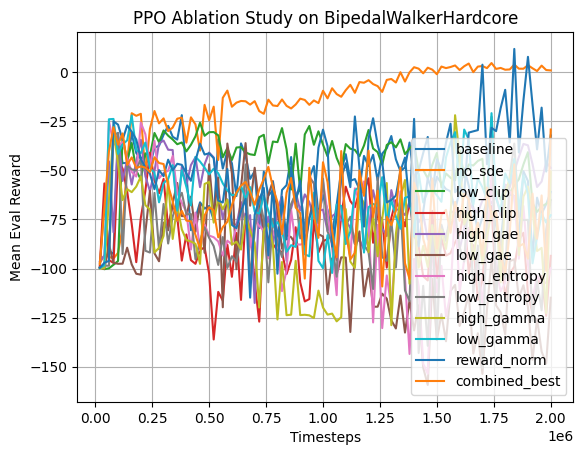

In [2]:
# This script restructures your training loop to:
# 1) Run a sweep of ablation experiments
# 2) Save evaluation results per ablation
# 3) Load results and plot comparisons
#
# IMPORTANT:
# - This is designed to be run as TWO phases:
#   (A) training_sweep.py
#   (B) analyze_results.py
#
# Below, BOTH are provided in one notebook-style execution for clarity.
# In practice, you may want to split them.

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
import torch.nn as nn

from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecNormalize
from stable_baselines3.common.callbacks import EvalCallback
from typing import Callable

# ===============================
# GLOBAL CONSTANTS
# ===============================
BASE_LOG_DIR = "./ablation_runs/"
TOTAL_TIMESTEPS = 2_000_000
N_ENVS = 8
SEED = 42

os.makedirs(BASE_LOG_DIR, exist_ok=True)

# ===============================
# LEARNING RATE SCHEDULE
# ===============================
def linear_schedule(initial_value: float, min_lr: float = 1e-5):
    def func(progress_remaining: float) -> float:
        return max(progress_remaining * initial_value, min_lr)
    return func

# ===============================
# POLICY KWARGS (SHARED)
# ===============================
def get_policy_kwargs():
    return dict(
        activation_fn=nn.Tanh,
        net_arch=dict(
            pi=[128, 128],
            vf=[256, 256],
        ),
        log_std_init=-1.5,
        ortho_init=False,
    )

# ===============================
# ABLATION CONFIGURATIONS
# ===============================
ABLATIONS = {
    "baseline": dict(
        ent_coef=0.002,
        use_sde=True,
        clip_range=0.25,
        gae_lambda=0.90,
        gamma=0.99,
        norm_reward=False,
    ),
    "no_sde": dict(
        ent_coef=0.002,
        use_sde=False,
        clip_range=0.25,
        gae_lambda=0.90,
        gamma=0.99,
        norm_reward=False,
    ),
    "low_clip": dict(
        ent_coef=0.002,
        use_sde=True,
        clip_range=0.1,
        gae_lambda=0.90,
        gamma=0.99,
        norm_reward=False,
    ),
    "high_clip": dict(
        ent_coef=0.002,
        use_sde=True,
        clip_range=0.35,
        gae_lambda=0.90,
        gamma=0.99,
        norm_reward=False,
    ),
    "high_gae": dict(
        ent_coef=0.002,
        use_sde=True,
        clip_range=0.25,
        gae_lambda=0.97,
        gamma=0.99,
        norm_reward=False,
    ),
    "low_gae": dict(
        ent_coef=0.002,
        use_sde=True,
        clip_range=0.25,
        gae_lambda=0.80,
        gamma=0.99,
        norm_reward=False,
    ),
    "high_entropy": dict(
        ent_coef=0.01,
        use_sde=True,
        clip_range=0.25,
        gae_lambda=0.90,
        gamma=0.99,
        norm_reward=False,
    ),
    "low_entropy": dict(
        ent_coef=0.0001,
        use_sde=True,
        clip_range=0.25,
        gae_lambda=0.90,
        gamma=0.99,
        norm_reward=False,
    ),
    "high_gamma": dict(
        ent_coef=0.002,
        use_sde=True,
        clip_range=0.25,
        gae_lambda=0.90,
        gamma=0.995,
        norm_reward=False,
    ),
    "low_gamma": dict(
        ent_coef=0.002,
        use_sde=True,
        clip_range=0.25,
        gae_lambda=0.90,
        gamma=0.98,
        norm_reward=False,
    ),
    "reward_norm": dict(
        ent_coef=0.002,
        use_sde=True,
        clip_range=0.25,
        gae_lambda=0.90,
        gamma=0.99,
        norm_reward=True,
    ),
    "combined_best": dict(
        ent_coef=0.01,
        use_sde=True,
        clip_range=0.25,
        gae_lambda=0.97,
        gamma=0.995,
        norm_reward=True,
    ),
}


# ===============================
# TRAINING LOOP
# ===============================
results_index = []

for name, cfg in ABLATIONS.items():
    print(f"\nRunning ablation: {name}")

    run_dir = os.path.join(BASE_LOG_DIR, name)
    os.makedirs(run_dir, exist_ok=True)

    # --- ENV ---
    env = make_vec_env(
        "BipedalWalkerHardcore-v3",
        n_envs=N_ENVS,
        seed=SEED,
    )
    env = VecNormalize(
        env,
        norm_obs=True,
        norm_reward=cfg["norm_reward"],
        gamma=cfg["gamma"],
        clip_obs=10.0,
    )

    eval_env = make_vec_env(
        "BipedalWalkerHardcore-v3",
        n_envs=1,
        seed=SEED + 100,
    )
    eval_env = VecNormalize(
        eval_env,
        norm_obs=True,
        norm_reward=False,
        training=False,
    )

    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path=os.path.join(run_dir, "best_model"),
        log_path=os.path.join(run_dir, "eval"),
        eval_freq=max(20_000 // N_ENVS, 1),
        deterministic=True,
    )

    # --- MODEL ---
    model = PPO(
        "MlpPolicy",
        env,
        learning_rate=linear_schedule(3e-4),
        n_steps=2048,
        batch_size=1024,
        n_epochs=10,
        gamma=cfg["gamma"],
        gae_lambda=cfg["gae_lambda"],
        clip_range=cfg["clip_range"],
        ent_coef=cfg["ent_coef"],
        vf_coef=0.5,
        max_grad_norm=0.5,
        use_sde=cfg["use_sde"],
        sde_sample_freq=4,
        seed=SEED,
        verbose=0,
        policy_kwargs=get_policy_kwargs(),
    )

    model.learn(TOTAL_TIMESTEPS, callback=eval_callback)

    model.save(os.path.join(run_dir, "final_model"))
    env.save(os.path.join(run_dir, "vec_normalize.pkl"))

    # Save config
    with open(os.path.join(run_dir, "config.json"), "w") as f:
        json.dump(cfg, f, indent=2)

    results_index.append({"run": name, **cfg})

# Save experiment index
pd.DataFrame(results_index).to_csv(
    os.path.join(BASE_LOG_DIR, "experiment_index.csv"),
    index=False,
)

print("\n✅ All ablation runs complete.")

# ===============================
# ANALYSIS + PLOTTING
# ===============================
print("\n📊 Analyzing results...")

def load_eval_results(run_name):
    eval_path = os.path.join(BASE_LOG_DIR, run_name, "eval", "evaluations.npz")
    data = np.load(eval_path)
    return data["timesteps"], data["results"].mean(axis=1)

plt.figure()
for run_name in ABLATIONS.keys():
    steps, rewards = load_eval_results(run_name)
    plt.plot(steps, rewards, label=run_name)

plt.xlabel("Timesteps")
plt.ylabel("Mean Eval Reward")
plt.title("PPO Ablation Study on BipedalWalkerHardcore")
plt.legend()
plt.grid(True)
plt.show()


In [4]:
import os
import numpy as np
import gymnasium as gym
import imageio
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import VecNormalize, DummyVecEnv
from tqdm import tqdm

# ===============================
# CONFIGURATION
# ===============================
BASE_LOG_DIR = "./ablation_runs/"
N_EPISODES = 3  # Number of episodes to record per ablation
MAX_STEPS = 2000  # Maximum steps per episode
FPS = 30  # Frames per second for GIF
DURATION_MS = 1000 / FPS  # Duration per frame in milliseconds

# List of ablations (should match your training script)
ABLATIONS = [
    "baseline",
    "no_sde",
    "low_clip",
    "high_clip",
    "high_gae",
    "low_gae",
    "high_entropy",
    "low_entropy",
    "high_gamma",
    "low_gamma",
    "reward_norm",
    "combined_best",
]


def create_gif_for_ablation(run_name, model_path, vec_normalize_path, output_path):
    """
    Create a GIF from a trained model's episodes.
    
    Args:
        run_name: Name of the ablation run
        model_path: Path to the saved model
        vec_normalize_path: Path to the VecNormalize wrapper
        output_path: Where to save the GIF
    """
    print(f"Creating GIF for {run_name}...")
    
    # Create environment with rendering
    def make_env():
        env = gym.make("BipedalWalkerHardcore-v3", render_mode="rgb_array")
        return env
    
    env = DummyVecEnv([make_env])
    
    # Load VecNormalize wrapper
    try:
        env = VecNormalize.load(vec_normalize_path, env)
        env.training = False
        env.norm_reward = False
    except FileNotFoundError:
        print(f"Warning: VecNormalize not found for {run_name}, using unnormalized env")
    
    # Load model
    try:
        model = PPO.load(model_path, env=env)
    except FileNotFoundError:
        print(f"Error: Model not found at {model_path}")
        return False
    
    # Collect frames from multiple episodes
    all_frames = []
    episode_rewards = []
    
    for episode in range(N_EPISODES):
        obs = env.reset()
        frames = []
        episode_reward = 0
        
        for step in range(MAX_STEPS):
            # Render frame
            frame = env.render()
            if isinstance(frame, list):
                frame = frame[0]
            frames.append(frame)
            
            # Get action from model
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, info = env.step(action)
            episode_reward += reward[0]
            
            if done[0]:
                break
        
        all_frames.extend(frames)
        episode_rewards.append(episode_reward)
        
        # Add a few black frames between episodes
        if episode < N_EPISODES - 1:
            black_frame = np.zeros_like(frames[0])
            all_frames.extend([black_frame] * 10)
    
    env.close()
    
    # Save as GIF
    if len(all_frames) > 0:
        imageio.mimsave(output_path, all_frames, duration=DURATION_MS)
        avg_reward = np.mean(episode_rewards)
        print(f"  ✓ Saved GIF to {output_path}")
        print(f"  Average reward across {N_EPISODES} episodes: {avg_reward:.2f}")
        return True
    else:
        print(f"  ✗ No frames collected for {run_name}")
        return False


def generate_all_gifs():
    """Generate GIFs for all ablation runs."""
    print("=" * 60)
    print("Generating GIFs for all ablation runs")
    print("=" * 60)
    
    success_count = 0
    
    for run_name in tqdm(ABLATIONS, desc="Overall Progress"):
        run_dir = os.path.join(BASE_LOG_DIR, run_name)
        
        # Try both "best_model" and "final_model"
        best_model_path = os.path.join(run_dir, "best_model", "best_model.zip")
        final_model_path = os.path.join(run_dir, "final_model.zip")
        
        # Use best model if available, otherwise use final
        if os.path.exists(best_model_path):
            model_path = best_model_path
            print(f"\nUsing best model for {run_name}")
        elif os.path.exists(final_model_path):
            model_path = final_model_path
            print(f"\nUsing final model for {run_name}")
        else:
            print(f"\n✗ No model found for {run_name}, skipping...")
            continue
        
        vec_normalize_path = os.path.join(run_dir, "vec_normalize.pkl")
        output_path = os.path.join(run_dir, f"{run_name}_demo.gif")
        
        success = create_gif_for_ablation(
            run_name, 
            model_path, 
            vec_normalize_path, 
            output_path
        )
        
        if success:
            success_count += 1
    
    print("\n" + "=" * 60)
    print(f"✅ Complete! Generated {success_count}/{len(ABLATIONS)} GIFs")
    print("=" * 60)


if __name__ == "__main__":
    # Check if base directory exists
    if not os.path.exists(BASE_LOG_DIR):
        print(f"Error: {BASE_LOG_DIR} does not exist. Please run training first.")
        exit(1)
    
    generate_all_gifs()
    
    print("\n📁 GIF locations:")
    for run_name in ABLATIONS:
        gif_path = os.path.join(BASE_LOG_DIR, run_name, f"{run_name}_demo.gif")
        if os.path.exists(gif_path):
            size_mb = os.path.getsize(gif_path) / (1024 * 1024)
            print(f"  • {gif_path} ({size_mb:.2f} MB)")

Generating GIFs for all ablation runs


Overall Progress:   0%|          | 0/12 [00:00<?, ?it/s]


Using best model for baseline
Creating GIF for baseline...
  ✓ Saved GIF to ./ablation_runs/baseline\baseline_demo.gif
  Average reward across 3 episodes: -80.27


Overall Progress:   8%|▊         | 1/12 [02:38<29:02, 158.42s/it]


Using best model for no_sde
Creating GIF for no_sde...
  ✓ Saved GIF to ./ablation_runs/no_sde\no_sde_demo.gif
  Average reward across 3 episodes: 0.50


...


Using best model for reward_norm
Creating GIF for reward_norm...
  ✓ Saved GIF to ./ablation_runs/reward_norm\reward_norm_demo.gif
  Average reward across 3 episodes: 6.48


Overall Progress:  92%|█████████▏| 11/12 [21:23<02:11, 131.89s/it]


Using best model for combined_best
Creating GIF for combined_best...


Overall Progress: 100%|██████████| 12/12 [21:29<00:00, 107.43s/it]

  ✓ Saved GIF to ./ablation_runs/combined_best\combined_best_demo.gif
  Average reward across 3 episodes: -100.24

✅ Complete! Generated 12/12 GIFs

📁 GIF locations:
  • ./ablation_runs/baseline\baseline_demo.gif (5.22 MB)
  • ./ablation_runs/no_sde\no_sde_demo.gif (3.41 MB)
  • ./ablation_runs/low_clip\low_clip_demo.gif (1.93 MB)
  • ./ablation_runs/high_clip\high_clip_demo.gif (1.69 MB)
  • ./ablation_runs/high_gae\high_gae_demo.gif (2.41 MB)
  • ./ablation_runs/low_gae\low_gae_demo.gif (8.74 MB)
  • ./ablation_runs/high_entropy\high_entropy_demo.gif (1.10 MB)
  • ./ablation_runs/low_entropy\low_entropy_demo.gif (3.16 MB)
  • ./ablation_runs/high_gamma\high_gamma_demo.gif (10.23 MB)
  • ./ablation_runs/low_gamma\low_gamma_demo.gif (7.80 MB)
  • ./ablation_runs/reward_norm\reward_norm_demo.gif (10.01 MB)
  • ./ablation_runs/combined_best\combined_best_demo.gif (0.61 MB)


Continuing training from: reward_norm
New run name: reward_norm_low_ent_high_gamma
Modified config: {
  "ent_coef": 0.0001,
  "use_sde": true,
  "clip_range": 0.25,
  "gae_lambda": 0.9,
  "gamma": 0.995,
  "norm_reward": true
}

✅ Loading model from: ./ablation_runs/reward_norm\best_model\best_model.zip
Loading VecNormalize stats from: ./ablation_runs/reward_norm\vec_normalize.pkl

📝 Updated hyperparameters:
  - Entropy coefficient: 0.0001 (LOW)
  - Gamma: 0.995 (HIGH)
  - Reward normalization: True
  - GAE lambda: 0.9
  - Clip range: <function get_clip_range.<locals>.func at 0x0000027F4282E200>

🚀 Starting continued training for 5,000,000 timesteps...
Eval num_timesteps=1860000, episode_reward=-120.58 +/- 14.82
Episode length: 758.00 +/- 631.85
New best mean reward!
Eval num_timesteps=1880000, episode_reward=-108.37 +/- 7.38
Episode length: 1017.00 +/- 803.07
New best mean reward!
Eval num_timesteps=1900000, episode_reward=-111.37 +/- 13.64
Episode length: 342.40 +/- 164.71
Eval num_t

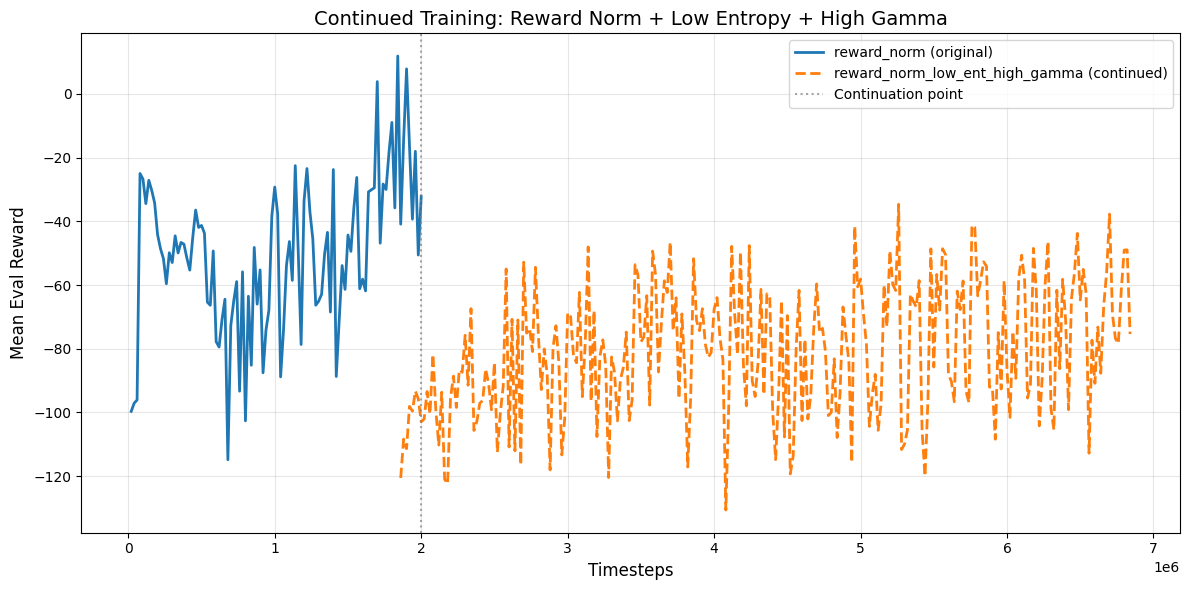


📈 Plot saved to: ./ablation_runs/reward_norm_low_ent_high_gamma\training_comparison.png


In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
import torch.nn as nn

from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecNormalize
from stable_baselines3.common.callbacks import EvalCallback
from typing import Callable

# ===============================
# CONFIGURATION
# ===============================
BASE_LOG_DIR = "./ablation_runs/"
CONTINUE_RUN_NAME = "reward_norm_low_ent_high_gamma"
CONTINUE_FROM = "reward_norm"  # Load the reward_norm best model
ADDITIONAL_TIMESTEPS = 5_000_000
N_ENVS = 8
SEED = 42

os.makedirs(BASE_LOG_DIR, exist_ok=True)

# ===============================
# LEARNING RATE SCHEDULE
# ===============================
def linear_schedule(initial_value: float, min_lr: float = 1e-5):
    def func(progress_remaining: float) -> float:
        return max(progress_remaining * initial_value, min_lr)
    return func

# ===============================
# POLICY KWARGS (SHARED)
# ===============================
def get_policy_kwargs():
    return dict(
        activation_fn=nn.Tanh,
        net_arch=dict(
            pi=[128, 128],
            vf=[256, 256],
        ),
        log_std_init=-1.5,
        ortho_init=False,
    )

# ===============================
# NEW CONFIGURATION
# ===============================
# Start from reward_norm config, but modify entropy and gamma
new_config = dict(
    ent_coef=0.0001,      # Low entropy (from low_entropy ablation)
    use_sde=True,
    clip_range=0.25,
    gae_lambda=0.90,
    gamma=0.995,          # High gamma (from high_gamma ablation)
    norm_reward=True,     # Keep reward normalization
)

print(f"Continuing training from: {CONTINUE_FROM}")
print(f"New run name: {CONTINUE_RUN_NAME}")
print(f"Modified config: {json.dumps(new_config, indent=2)}")

# ===============================
# LOAD PREVIOUS MODEL
# ===============================
previous_run_dir = os.path.join(BASE_LOG_DIR, CONTINUE_FROM)
best_model_path = os.path.join(previous_run_dir, "best_model", "best_model.zip")
vec_normalize_path = os.path.join(previous_run_dir, "vec_normalize.pkl")

if not os.path.exists(best_model_path):
    raise FileNotFoundError(f"Best model not found at {best_model_path}")

print(f"\n✅ Loading model from: {best_model_path}")

# ===============================
# SETUP NEW ENVIRONMENT
# ===============================
new_run_dir = os.path.join(BASE_LOG_DIR, CONTINUE_RUN_NAME)
os.makedirs(new_run_dir, exist_ok=True)

env = make_vec_env(
    "BipedalWalkerHardcore-v3",
    n_envs=N_ENVS,
    seed=SEED,
)
env = VecNormalize(
    env,
    norm_obs=True,
    norm_reward=new_config["norm_reward"],
    gamma=new_config["gamma"],
    clip_obs=10.0,
)

# Load the normalization stats from previous run if available
if os.path.exists(vec_normalize_path):
    print(f"Loading VecNormalize stats from: {vec_normalize_path}")
    env = VecNormalize.load(vec_normalize_path, env)
    env.training = True
    env.norm_reward = new_config["norm_reward"]

eval_env = make_vec_env(
    "BipedalWalkerHardcore-v3",
    n_envs=1,
    seed=SEED + 100,
)
eval_env = VecNormalize(
    eval_env,
    norm_obs=True,
    norm_reward=False,
    training=False,
)

if os.path.exists(vec_normalize_path):
    eval_env = VecNormalize.load(vec_normalize_path, eval_env)
    eval_env.training = False
    eval_env.norm_reward = False

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=os.path.join(new_run_dir, "best_model"),
    log_path=os.path.join(new_run_dir, "eval"),
    eval_freq=max(20_000 // N_ENVS, 1),
    deterministic=True,
)

# ===============================
# LOAD MODEL AND UPDATE PARAMETERS
# ===============================

# Create clip_range as a callable function
def get_clip_range(clip_value: float):
    def func(progress_remaining: float) -> float:
        return clip_value
    return func

model = PPO.load(
    best_model_path,
    env=env,
    custom_objects={
        "learning_rate": linear_schedule(3e-4),
        "clip_range": get_clip_range(new_config["clip_range"]),
    }
)

# Update the hyperparameters for continued training
model.gamma = new_config["gamma"]
model.gae_lambda = new_config["gae_lambda"]
model.clip_range = get_clip_range(new_config["clip_range"])
model.ent_coef = new_config["ent_coef"]
model.use_sde = new_config["use_sde"]

print(f"\n📝 Updated hyperparameters:")
print(f"  - Entropy coefficient: {model.ent_coef} (LOW)")
print(f"  - Gamma: {model.gamma} (HIGH)")
print(f"  - Reward normalization: {new_config['norm_reward']}")
print(f"  - GAE lambda: {model.gae_lambda}")
print(f"  - Clip range: {model.clip_range}")

# ===============================
# CONTINUE TRAINING
# ===============================
print(f"\n🚀 Starting continued training for {ADDITIONAL_TIMESTEPS:,} timesteps...")

model.learn(
    total_timesteps=ADDITIONAL_TIMESTEPS,
    callback=eval_callback,
    reset_num_timesteps=False,  # Continue from previous timestep count
)

# ===============================
# SAVE RESULTS
# ===============================
model.save(os.path.join(new_run_dir, "final_model"))
env.save(os.path.join(new_run_dir, "vec_normalize.pkl"))

# Save config with metadata
config_with_meta = {
    **new_config,
    "continued_from": CONTINUE_FROM,
    "additional_timesteps": ADDITIONAL_TIMESTEPS,
    "total_timesteps": ADDITIONAL_TIMESTEPS + 2_000_000,
}
with open(os.path.join(new_run_dir, "config.json"), "w") as f:
    json.dump(config_with_meta, f, indent=2)

print(f"\n✅ Continued training complete! Results saved to: {new_run_dir}")

# ===============================
# PLOT COMPARISON
# ===============================
print("\n📊 Plotting comparison...")

def load_eval_results(run_name):
    eval_path = os.path.join(BASE_LOG_DIR, run_name, "eval", "evaluations.npz")
    if not os.path.exists(eval_path):
        return None, None
    data = np.load(eval_path)
    return data["timesteps"], data["results"].mean(axis=1)

plt.figure(figsize=(12, 6))

# Plot original reward_norm run
steps_orig, rewards_orig = load_eval_results(CONTINUE_FROM)
if steps_orig is not None:
    plt.plot(steps_orig, rewards_orig, label=f"{CONTINUE_FROM} (original)", linewidth=2)

# Plot continued run
steps_cont, rewards_cont = load_eval_results(CONTINUE_RUN_NAME)
if steps_cont is not None:
    plt.plot(steps_cont, rewards_cont, label=f"{CONTINUE_RUN_NAME} (continued)", linewidth=2, linestyle='--')

# Add vertical line showing where continuation started
if steps_orig is not None and len(steps_orig) > 0:
    plt.axvline(x=steps_orig[-1], color='gray', linestyle=':', alpha=0.7, label='Continuation point')

plt.xlabel("Timesteps", fontsize=12)
plt.ylabel("Mean Eval Reward", fontsize=12)
plt.title("Continued Training: Reward Norm + Low Entropy + High Gamma", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(new_run_dir, "training_comparison.png"), dpi=150)
plt.show()

print(f"\n📈 Plot saved to: {os.path.join(new_run_dir, 'training_comparison.png')}")

📂 Loading model from: reward_norm
✅ Model loaded successfully
   Total timesteps already trained: 1840000

🚀 Continuing training for 2,000,000 timesteps
Eval num_timesteps=1860000, episode_reward=-71.96 +/- 18.81
Episode length: 1073.80 +/- 799.89
New best mean reward!
Eval num_timesteps=1880000, episode_reward=-6.39 +/- 23.70
Episode length: 1839.60 +/- 320.80
New best mean reward!
Eval num_timesteps=1900000, episode_reward=-47.88 +/- 15.48
Episode length: 1351.80 +/- 795.03
Eval num_timesteps=1920000, episode_reward=-14.50 +/- 97.10
Episode length: 1295.20 +/- 863.55
Eval num_timesteps=1940000, episode_reward=-76.35 +/- 6.60
Episode length: 957.00 +/- 851.95
Eval num_timesteps=1960000, episode_reward=12.03 +/- 66.65
Episode length: 1495.60 +/- 699.55
New best mean reward!
Eval num_timesteps=1980000, episode_reward=-43.71 +/- 41.17
Episode length: 906.60 +/- 657.97
Eval num_timesteps=2000000, episode_reward=9.90 +/- 61.56
Episode length: 1446.60 +/- 729.01
Eval num_timesteps=2020000, 

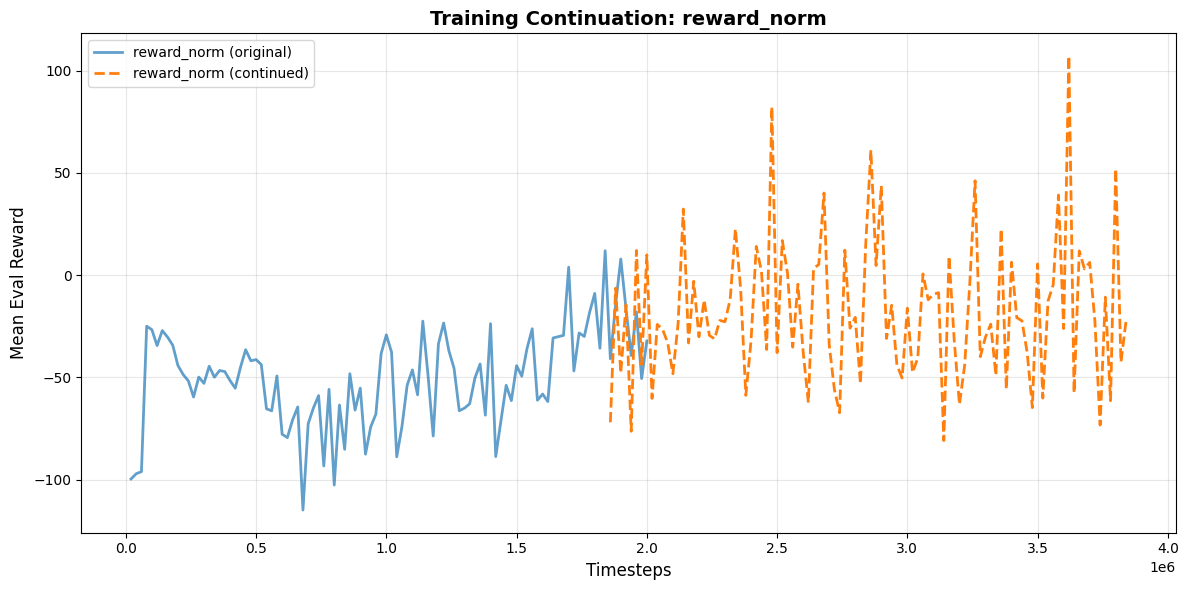


📈 Performance Summary:
   Original run final reward: -32.20
   Continued run final reward: -21.87
   Improvement: 10.33
   Original run max reward: 11.91
   Continued run max reward: 107.12


In [15]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import torch.nn as nn

from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecNormalize
from stable_baselines3.common.callbacks import EvalCallback
from typing import Callable

# ===============================
# CONFIGURATION
# ===============================
BASE_LOG_DIR = "./ablation_runs/"
CONTINUE_RUN = "reward_norm"  # The run to continue from
CONTINUE_DIR = os.path.join(BASE_LOG_DIR, CONTINUE_RUN + "_continued")
ADDITIONAL_TIMESTEPS = 2_000_000  # Additional training time
N_ENVS = 8
SEED = 42

os.makedirs(CONTINUE_DIR, exist_ok=True)

# ===============================
# LEARNING RATE SCHEDULE
# ===============================
def linear_schedule(initial_value: float, min_lr: float = 1e-5):
    def func(progress_remaining: float) -> float:
        return max(progress_remaining * initial_value, min_lr)
    return func

# ===============================
# LOAD PREVIOUS MODEL
# ===============================
print(f"📂 Loading model from: {CONTINUE_RUN}")

original_run_dir = os.path.join(BASE_LOG_DIR, CONTINUE_RUN)
best_model_path = os.path.join(original_run_dir, "best_model", "best_model.zip")
vec_normalize_path = os.path.join(original_run_dir, "vec_normalize.pkl")

# Check if files exist
if not os.path.exists(best_model_path):
    raise FileNotFoundError(f"Model not found at {best_model_path}")
if not os.path.exists(vec_normalize_path):
    raise FileNotFoundError(f"VecNormalize not found at {vec_normalize_path}")

# Load the trained model
model = PPO.load(best_model_path)

# Load the VecNormalize statistics
env = make_vec_env(
    "BipedalWalkerHardcore-v3",
    n_envs=N_ENVS,
    seed=SEED,
)
env = VecNormalize.load(vec_normalize_path, env)

# Ensure training mode is on
env.training = True
env.norm_reward = True

print(f"✅ Model loaded successfully")
print(f"   Total timesteps already trained: {model.num_timesteps}")

# ===============================
# SETUP EVALUATION
# ===============================
eval_env = make_vec_env(
    "BipedalWalkerHardcore-v3",
    n_envs=1,
    seed=SEED + 200,
)
eval_env = VecNormalize(
    eval_env,
    norm_obs=True,
    norm_reward=False,
    training=False,
)

# Copy normalization stats from training env
eval_env.obs_rms = env.obs_rms
eval_env.ret_rms = env.ret_rms

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=os.path.join(CONTINUE_DIR, "best_model"),
    log_path=os.path.join(CONTINUE_DIR, "eval"),
    eval_freq=max(20_000 // N_ENVS, 1),
    deterministic=True,
    verbose=1,
)

# ===============================
# CONTINUE TRAINING
# ===============================
print(f"\n🚀 Continuing training for {ADDITIONAL_TIMESTEPS:,} timesteps")

# Set the environment for the model
model.set_env(env)

# Continue learning
model.learn(
    total_timesteps=ADDITIONAL_TIMESTEPS,
    callback=eval_callback,
    reset_num_timesteps=False,  # Don't reset timestep counter
)

# ===============================
# SAVE CONTINUED MODEL
# ===============================
model.save(os.path.join(CONTINUE_DIR, "final_model"))
env.save(os.path.join(CONTINUE_DIR, "vec_normalize.pkl"))

# Save metadata
metadata = {
    "original_run": CONTINUE_RUN,
    "original_timesteps": model.num_timesteps - ADDITIONAL_TIMESTEPS,
    "additional_timesteps": ADDITIONAL_TIMESTEPS,
    "total_timesteps": model.num_timesteps,
    "continued_from": "best_model",
}

with open(os.path.join(CONTINUE_DIR, "continue_metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2)

print(f"\n✅ Continued training complete!")
print(f"   Total timesteps: {model.num_timesteps:,}")
print(f"   Saved to: {CONTINUE_DIR}")

# ===============================
# PLOT COMPARISON
# ===============================
print("\n📊 Plotting comparison...")

def load_eval_results(run_dir):
    """Load evaluation results from a run directory"""
    eval_path = os.path.join(run_dir, "eval", "evaluations.npz")
    if not os.path.exists(eval_path):
        return None, None
    data = np.load(eval_path)
    return data["timesteps"], data["results"].mean(axis=1)

# Load original run results
original_steps, original_rewards = load_eval_results(original_run_dir)

# Load continued run results
continued_steps, continued_rewards = load_eval_results(CONTINUE_DIR)

# Create comparison plot
plt.figure(figsize=(12, 6))

if original_steps is not None:
    plt.plot(original_steps, original_rewards, 
             label=f'{CONTINUE_RUN} (original)', 
             linewidth=2, alpha=0.7)

if continued_steps is not None:
    plt.plot(continued_steps, continued_rewards, 
             label=f'{CONTINUE_RUN} (continued)', 
             linewidth=2, linestyle='--')

plt.xlabel("Timesteps", fontsize=12)
plt.ylabel("Mean Eval Reward", fontsize=12)
plt.title(f"Training Continuation: {CONTINUE_RUN}", fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save plot
plot_path = os.path.join(CONTINUE_DIR, "training_comparison.png")
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"📈 Plot saved to: {plot_path}")

plt.show()

# ===============================
# PRINT SUMMARY STATISTICS
# ===============================
if original_rewards is not None and continued_rewards is not None:
    print("\n📈 Performance Summary:")
    print(f"   Original run final reward: {original_rewards[-1]:.2f}")
    print(f"   Continued run final reward: {continued_rewards[-1]:.2f}")
    print(f"   Improvement: {continued_rewards[-1] - original_rewards[-1]:.2f}")
    print(f"   Original run max reward: {original_rewards.max():.2f}")
    print(f"   Continued run max reward: {continued_rewards.max():.2f}")

Observation shape: (24,)
EXPERIMENT 1: Immediate Gamma Change (0.99 → 0.995)
✅ Loaded model from reward_norm_continued
   Starting timesteps: 3,620,000
   Original gamma: 0.99
   ➡️  New gamma: 0.995

🚀 Training with gamma=0.995 for 2,000,000 timesteps...
Eval num_timesteps=3640000, episode_reward=-47.13 +/- 26.85
Episode length: 1677.80 +/- 644.40
New best mean reward!
Eval num_timesteps=3660000, episode_reward=-45.03 +/- 44.93
Episode length: 1643.40 +/- 713.20
New best mean reward!
Eval num_timesteps=3680000, episode_reward=-0.15 +/- 75.90
Episode length: 2000.00 +/- 0.00
New best mean reward!
Eval num_timesteps=3700000, episode_reward=-43.28 +/- 21.14
Episode length: 2000.00 +/- 0.00
Eval num_timesteps=3720000, episode_reward=3.16 +/- 42.88
Episode length: 1877.80 +/- 244.40
New best mean reward!
Eval num_timesteps=3740000, episode_reward=-30.25 +/- 89.97
Episode length: 1365.40 +/- 785.02
Eval num_timesteps=3760000, episode_reward=-74.49 +/- 9.00
Episode length: 1273.80 +/- 889.43

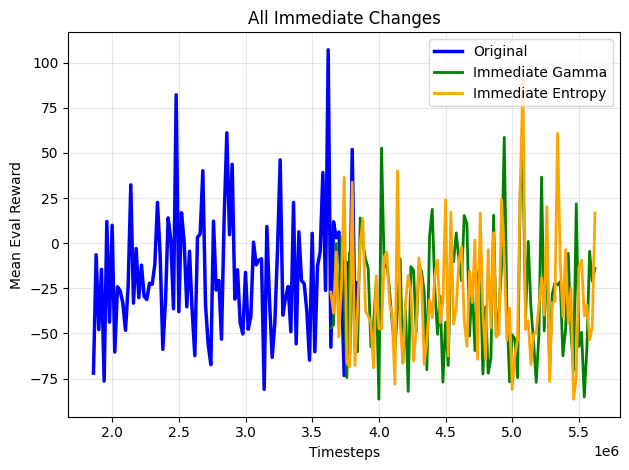


SUMMARY STATISTICS

📊 Original (reward_norm):
   Final reward: -21.87
   Max reward: 107.12

IMMEDIATE CHANGES

📊 Immediate Gamma (0.99→0.995):
   Final reward: -13.84
   Max reward: 58.62
   Improvement: +8.03

📊 Immediate Entropy (0.002→0.001):
   Final reward: 16.78
   Max reward: 89.86
   Improvement: +38.65

✅ All experiments complete!


In [2]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import torch.nn as nn

from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecNormalize
from stable_baselines3.common.callbacks import EvalCallback
from typing import Callable


e = gym.make("BipedalWalkerHardcore-v3")
o, _ = e.reset()
print(f"Observation shape: {o.shape}") # Should be (24,)

# ===============================
# CONFIGURATION
# ===============================
BASE_LOG_DIR = "./ablation_runs/"
CONTINUE_RUN = "reward_norm_continued"
ADDITIONAL_TIMESTEPS = 2_000_000
N_ENVS = 8
SEED = 42

# ===============================
# HELPER FUNCTIONS
# ===============================
def linear_schedule(initial_value: float, min_lr: float = 1e-5):
    def func(progress_remaining: float) -> float:
        return max(progress_remaining * initial_value, min_lr)
    return func

def create_env():
    # Explicitly create the env to ensure no version conflicts
    env = gym.make("BipedalWalkerHardcore-v3")
    return env
def load_model_and_env(run_name, seed):
    run_dir = os.path.join(BASE_LOG_DIR, run_name)
    vec_normalize_path = os.path.join(run_dir, "vec_normalize.pkl")
    
    # Use the lambda format for make_vec_env, it's more stable for Box2D
    env = make_vec_env(lambda: gym.make("BipedalWalkerHardcore-v3"), n_envs=N_ENVS, seed=seed)
    
    if os.path.exists(vec_normalize_path):
        env = VecNormalize.load(vec_normalize_path, env)
    
    best_model_path = os.path.join(run_dir, "best_model", "best_model.zip")
    model = PPO.load(best_model_path, env=env)
    
    return model, env

def create_eval_env(seed, obs_rms=None, ret_rms=None):
    # FIX: Ensure render_mode is None for training/eval unless needed
    eval_env = make_vec_env("BipedalWalkerHardcore-v3", n_envs=1, seed=seed)
    eval_env = VecNormalize(eval_env, norm_obs=True, norm_reward=False, training=False)
    
    if obs_rms is not None:
        eval_env.obs_rms = obs_rms
    # Note: ret_rms is usually not needed for EvalEnv as norm_reward=False
    
    return eval_env

def train_with_modified_params(run_name, model, env, additional_timesteps, param_changes):
    """Train model with immediately changed parameters"""
    run_dir = os.path.join(BASE_LOG_DIR, run_name)
    os.makedirs(run_dir, exist_ok=True)
    
    # Setup evaluation
    eval_env = create_eval_env(SEED + 400, env.obs_rms, env.ret_rms)
    
    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path=os.path.join(run_dir, "best_model"),
        log_path=os.path.join(run_dir, "eval"),
        eval_freq=max(20_000 // N_ENVS, 1),
        deterministic=True,
        verbose=1,
    )
    
    # Set environment and train
    model.set_env(env)
    model.learn(
        total_timesteps=additional_timesteps,
        callback=eval_callback,
        reset_num_timesteps=False,
    )
    
    # Save results
    model.save(os.path.join(run_dir, "final_model"))
    env.save(os.path.join(run_dir, "vec_normalize.pkl"))
    
    # Save metadata
    metadata = {
        "base_run": CONTINUE_RUN,
        "parameter_changes": param_changes,
        "additional_timesteps": additional_timesteps,
        "total_timesteps": model.num_timesteps,
    }
    with open(os.path.join(run_dir, "metadata.json"), "w") as f:
        json.dump(metadata, f, indent=2)
    
    return model, run_dir


# ===============================
# EXPERIMENT 1: IMMEDIATE GAMMA CHANGE
# ===============================
print("=" * 60)
print("EXPERIMENT 1: Immediate Gamma Change (0.99 → 0.995)")
print("=" * 60)

model_gamma, env_gamma = load_model_and_env(CONTINUE_RUN, SEED)
print(f"✅ Loaded model from {CONTINUE_RUN}")
print(f"   Starting timesteps: {model_gamma.num_timesteps:,}")
print(f"   Original gamma: {model_gamma.gamma}")

# IMMEDIATELY change gamma
NEW_GAMMA = 0.995
model_gamma.gamma = NEW_GAMMA

# Also update VecNormalize gamma for reward normalization
if hasattr(env_gamma, 'gamma'):
    env_gamma.gamma = NEW_GAMMA

print(f"   ➡️  New gamma: {model_gamma.gamma}")

param_changes_gamma = {
    "parameter": "gamma",
    "original_value": 0.99,
    "new_value": NEW_GAMMA,
    "change_type": "immediate"
}

print(f"\n🚀 Training with gamma={NEW_GAMMA} for {ADDITIONAL_TIMESTEPS:,} timesteps...")

model_gamma, gamma_dir = train_with_modified_params(
    "reward_norm_immediate_gamma",
    model_gamma,
    env_gamma,
    ADDITIONAL_TIMESTEPS,
    param_changes_gamma
)

print(f"✅ Immediate gamma training complete!")
print(f"   Final timesteps: {model_gamma.num_timesteps:,}")
print(f"   Saved to: {gamma_dir}")


# ===============================
# EXPERIMENT 2: IMMEDIATE ENTROPY CHANGE
# ===============================
print("\n" + "=" * 60)
print("EXPERIMENT 2: Immediate Entropy Change (0.002 → 0.001)")
print("=" * 60)

model_entropy, env_entropy = load_model_and_env(CONTINUE_RUN, SEED + 1)
print(f"✅ Loaded model from {CONTINUE_RUN}")
print(f"   Starting timesteps: {model_entropy.num_timesteps:,}")
print(f"   Original entropy coef: {model_entropy.ent_coef}")

# IMMEDIATELY change entropy coefficient
NEW_ENT_COEF = 0.001
model_entropy.ent_coef = NEW_ENT_COEF

print(f"   ➡️  New entropy coef: {model_entropy.ent_coef}")

param_changes_entropy = {
    "parameter": "ent_coef",
    "original_value": 0.002,
    "new_value": NEW_ENT_COEF,
    "change_type": "immediate"
}

print(f"\n🚀 Training with ent_coef={NEW_ENT_COEF} for {ADDITIONAL_TIMESTEPS:,} timesteps...")

model_entropy, entropy_dir = train_with_modified_params(
    "reward_norm_immediate_entropy",
    model_entropy,
    env_entropy,
    ADDITIONAL_TIMESTEPS,
    param_changes_entropy
)

print(f"✅ Immediate entropy training complete!")
print(f"   Final timesteps: {model_entropy.num_timesteps:,}")
print(f"   Saved to: {entropy_dir}")



# ===============================
# VISUALIZATION
# ===============================
print("\n" + "=" * 60)
print("CREATING VISUALIZATIONS")
print("=" * 60)

def load_eval_results(run_dir):
    """Load evaluation results"""
    eval_path = os.path.join(run_dir, "eval", "evaluations.npz")
    if not os.path.exists(eval_path):
        return None, None
    data = np.load(eval_path)
    return data["timesteps"], data["results"].mean(axis=1)

# Load all results
original_dir = os.path.join(BASE_LOG_DIR, CONTINUE_RUN)
orig_steps, orig_rewards = load_eval_results(original_dir)
gamma_steps, gamma_rewards = load_eval_results(gamma_dir)
entropy_steps, entropy_rewards = load_eval_results(entropy_dir)

# Create comprehensive comparison plot
fig, ax = plt.subplots(1, 1)

# Plot 3: All immediate changes together
if orig_steps is not None:
    ax.plot(orig_steps, orig_rewards, label='Original', linewidth=2.5, color='blue')
if gamma_steps is not None:
    ax.plot(gamma_steps, gamma_rewards, label='Immediate Gamma', linewidth=2, color='green')
if entropy_steps is not None:
    ax.plot(entropy_steps, entropy_rewards, label='Immediate Entropy', linewidth=2, color='orange')
ax.set_xlabel("Timesteps")
ax.set_ylabel("Mean Eval Reward")
ax.set_title("All Immediate Changes")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(BASE_LOG_DIR, "immediate_vs_adaptive_comparison.png")
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"📈 Comparison plot saved to: {plot_path}")
plt.show()

# ===============================
# SUMMARY STATISTICS
# ===============================
print("\n" + "=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)

if orig_rewards is not None:
    print(f"\n📊 Original (reward_norm):")
    print(f"   Final reward: {orig_rewards[-1]:.2f}")
    print(f"   Max reward: {orig_rewards.max():.2f}")

print(f"\n{'='*30}")
print("IMMEDIATE CHANGES")
print(f"{'='*30}")

if gamma_rewards is not None:
    print(f"\n📊 Immediate Gamma (0.99→0.995):")
    print(f"   Final reward: {gamma_rewards[-1]:.2f}")
    print(f"   Max reward: {gamma_rewards.max():.2f}")
    if orig_rewards is not None:
        print(f"   Improvement: {gamma_rewards[-1] - orig_rewards[-1]:+.2f}")

if entropy_rewards is not None:
    print(f"\n📊 Immediate Entropy (0.002→0.001):")
    print(f"   Final reward: {entropy_rewards[-1]:.2f}")
    print(f"   Max reward: {entropy_rewards.max():.2f}")
    if orig_rewards is not None:
        print(f"   Improvement: {entropy_rewards[-1] - orig_rewards[-1]:+.2f}")


print("\n✅ All experiments complete!")


CREATING VISUALIZATIONS
📈 Comparison plot saved to: ./ablation_runs/immediate_vs_adaptive_comparison.png


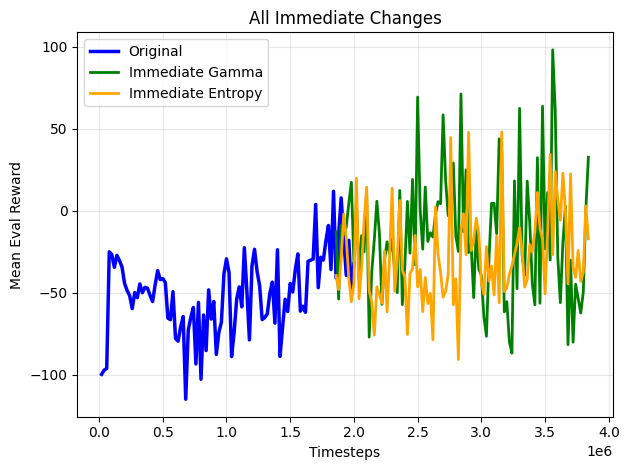


SUMMARY STATISTICS

📊 Original (reward_norm):
   Final reward: -32.20
   Max reward: 11.91

IMMEDIATE CHANGES

📊 Immediate Gamma (0.99→0.995):
   Final reward: 32.67
   Max reward: 98.17
   Improvement: +64.86

📊 Immediate Entropy (0.002→0.001):
   Final reward: -17.06
   Max reward: 48.05
   Improvement: +15.14

✅ All experiments complete!


In [25]:

# ===============================
# VISUALIZATION
# ===============================
print("\n" + "=" * 60)
print("CREATING VISUALIZATIONS")
print("=" * 60)

def load_eval_results(run_dir):
    """Load evaluation results"""
    eval_path = os.path.join(run_dir, "eval", "evaluations.npz")
    if not os.path.exists(eval_path):
        return None, None
    data = np.load(eval_path)
    return data["timesteps"], data["results"].mean(axis=1)

# Load all results
original_dir = os.path.join(BASE_LOG_DIR, CONTINUE_RUN)
orig_steps, orig_rewards = load_eval_results(original_dir)
gamma_steps, gamma_rewards = load_eval_results(gamma_dir)
entropy_steps, entropy_rewards = load_eval_results(entropy_dir)

# Create comprehensive comparison plot
fig, ax = plt.subplots(1, 1)

# Plot 3: All immediate changes together
if orig_steps is not None:
    ax.plot(orig_steps, orig_rewards, label='Original', linewidth=2.5, color='blue')
if gamma_steps is not None:
    ax.plot(gamma_steps, gamma_rewards, label='Immediate Gamma', linewidth=2, color='green')
if entropy_steps is not None:
    ax.plot(entropy_steps, entropy_rewards, label='Immediate Entropy', linewidth=2, color='orange')
ax.set_xlabel("Timesteps")
ax.set_ylabel("Mean Eval Reward")
ax.set_title("All Immediate Changes")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(BASE_LOG_DIR, "immediate_vs_adaptive_comparison.png")
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"📈 Comparison plot saved to: {plot_path}")
plt.show()

# ===============================
# SUMMARY STATISTICS
# ===============================
print("\n" + "=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)

if orig_rewards is not None:
    print(f"\n📊 Original (reward_norm):")
    print(f"   Final reward: {orig_rewards[-1]:.2f}")
    print(f"   Max reward: {orig_rewards.max():.2f}")

print(f"\n{'='*30}")
print("IMMEDIATE CHANGES")
print(f"{'='*30}")

if gamma_rewards is not None:
    print(f"\n📊 Immediate Gamma (0.99→0.995):")
    print(f"   Final reward: {gamma_rewards[-1]:.2f}")
    print(f"   Max reward: {gamma_rewards.max():.2f}")
    if orig_rewards is not None:
        print(f"   Improvement: {gamma_rewards[-1] - orig_rewards[-1]:+.2f}")

if entropy_rewards is not None:
    print(f"\n📊 Immediate Entropy (0.002→0.001):")
    print(f"   Final reward: {entropy_rewards[-1]:.2f}")
    print(f"   Max reward: {entropy_rewards.max():.2f}")
    if orig_rewards is not None:
        print(f"   Improvement: {entropy_rewards[-1] - orig_rewards[-1]:+.2f}")


print("\n✅ All experiments complete!")